# Variación diacrónica

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import requests
import numpy as np
import re
import mwparserfromhell
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from matplotlib.pyplot import hist

## Configuración

In [ ]:
HEADERS = {"User-Agent": "WikiBiasAnalysis/1.0 (research project; candela.welsh@outlook.com)"}

# Artículos a analizar
PAR_TITLES = [
    "Holodomor",
    "United States and state-sponsored terrorism",
]

# ── Parámetros de detección automática de snapshots ──────────────────────
MAX_SNAPSHOTS = None
HIGH_DENSITY_THRESHOLD = 20
PEAK_SENSITIVITY = 1.0

THRESHOLD = 0.80

MODEL_NAME = "all-mpnet-base-v2"


## API MediaWiki: recuperación de revisiones

In [ ]:
def get_revision_history(title: str) -> pd.DataFrame:
    """
    Recupera el historial completo de revisiones de un artículo (metadatos).

    Pagina automáticamente hasta obtener todas las revisiones disponibles.
    Devuelve DataFrame con columnas: revid, timestamp, user, size, comment.
    """
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "titles": title,
        "prop": "revisions",
        "rvprop": "ids|timestamp|user|size|comment",
        "rvlimit": 500,
        "rvdir": "newer",
        "format": "json",
    }
    revisions = []
    while True:
        response = requests.get(url, params=params, headers=HEADERS, timeout=30)
        response.raise_for_status()
        data = response.json()
        page = next(iter(data["query"]["pages"].values()))
        if "missing" in page:
            raise ValueError(f"Artículo no encontrado: '{title}'")
        revisions.extend(page.get("revisions", []))
        if "continue" not in data:
            break
        params["rvcontinue"] = data["continue"]["rvcontinue"]
    return pd.DataFrame(revisions)


def get_revision_at_date(title: str, date: str) -> tuple[int, str]:
    """
    Devuelve (revid, timestamp) de la revisión más reciente anterior a `date`.
    """
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "titles": title,
        "prop": "revisions",
        "rvprop": "ids|timestamp|size",
        "rvlimit": 1,
        "rvdir": "older",
        "rvstart": date,
        "format": "json",
    }
    response = requests.get(url, params=params, headers=HEADERS, timeout=30)
    response.raise_for_status()
    data = response.json()
    page = next(iter(data["query"]["pages"].values()))
    if "missing" in page:
        raise ValueError(f"Artículo no encontrado: '{title}'")
    if "revisions" not in page or len(page["revisions"]) == 0:
        raise ValueError(f"No hay revisión para '{title}' anterior a {date}")
    rev = page["revisions"][0]
    return rev["revid"], rev["timestamp"]


def get_revision_text(revid: int) -> str:
    """Devuelve el wikitext crudo de una revisión dado su revid."""
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "revids": revid,
        "prop": "revisions",
        "rvprop": "content",
        "rvslots": "main",
        "format": "json",
    }
    response = requests.get(url, params=params, headers=HEADERS, timeout=30)
    response.raise_for_status()
    data = response.json()
    page = next(iter(data["query"]["pages"].values()))
    return page["revisions"][0]["slots"]["main"]["*"]


# ── Detección automática de snapshots ────────────────────────────────────

def compute_edit_score(hist: pd.DataFrame, freq: str) -> pd.Series:
    """
    Construye la puntuación compuesta de actividad editorial por periodo.

    score = 0.5 * ediciones_normalizadas + 0.5 * variación_tamaño_normalizada

    Ambas señales se normalizan al rango [0, 1] para que tengan el mismo peso.
    """
    hist = hist.copy()
    hist["timestamp"] = pd.to_datetime(hist["timestamp"])
    hist["size"] = pd.to_numeric(hist["size"], errors="coerce").fillna(0)
    hist = hist.sort_values("timestamp")
    hist["size_delta"] = hist["size"].diff().abs().fillna(0)
    hist = hist.set_index("timestamp")

    edit_count = hist["revid"].resample(freq).count()
    size_change = hist["size_delta"].resample(freq).sum()

    def norm(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else s * 0

    score = 0.5 * norm(edit_count) + 0.5 * norm(size_change)
    return score


def detect_snapshot_dates(
    title: str,
    max_snapshots: int | None = MAX_SNAPSHOTS,
    high_density_threshold: float = HIGH_DENSITY_THRESHOLD,
    peak_sensitivity: float = PEAK_SENSITIVITY,
) -> list[str]:
    """
    Determina automáticamente las fechas de snapshot para un artículo.
    """
    hist = get_revision_history(title)
    hist["timestamp"] = pd.to_datetime(hist["timestamp"])
    hist = hist.sort_values("timestamp").reset_index(drop=True)

    # Densidad media: ediciones por mes
    total_months = max(
        (hist["timestamp"].iloc[-1] - hist["timestamp"].iloc[0]).days / 30, 1
    )
    density = len(hist) / total_months

    freq = "QE" if density >= high_density_threshold else "ME"
    print(f"  {title[:40]} | densidad={density:.1f} edits/mes → granularidad {'trimestral' if freq == 'QE' else 'mensual'}")

    score = compute_edit_score(hist, freq)

    # Detectar picos
    threshold = score.mean() + peak_sensitivity * score.std()
    peak_periods = score[score > threshold].sort_values(ascending=False)

    # Fecha de snapshot = inicio del periodo pico
    peak_dates = [p.strftime("%Y-%m-%dT00:00:00Z") for p in peak_periods.index]

    # Extremos: primera revisión y hoy
    first_date = str(hist["timestamp"].iloc[0].date()) + "T00:00:00Z"
    today = pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%dT00:00:00Z")

    all_dates = sorted(set([first_date] + peak_dates + [today]))

    # Aplicar límite si está definido
    if max_snapshots is not None and len(all_dates) > max_snapshots:
        # Conservar inicio, fin y los picos de mayor score hasta completar
        top_peaks = [str(p.to_period(freq).start_time.date()) + "T00:00:00Z"
                     for p in peak_periods.head(max_snapshots - 2).index]
        all_dates = sorted(set([first_date] + top_peaks + [today]))

    print(f"  → {len(all_dates)} snapshots detectados")
    return all_dates


# Generar SNAPSHOTS automáticamente para todos los artículos
print("Detectando snapshots automáticamente...\n")
SNAPSHOTS = {}
for title in PAR_TITLES:
    SNAPSHOTS[title] = detect_snapshot_dates(title)


Detectando snapshots automáticamente...

  Holodomor | densidad=31.9 edits/mes → granularidad trimestral
  → 14 snapshots detectados
  United States and state-sponsored terror | densidad=4.1 edits/mes → granularidad mensual
  → 10 snapshots detectados


In [10]:
for title, dates in SNAPSHOTS.items():
    print(f"\n{title}")
    for d in dates:
        print(f"  {d[:10]}")


Holodomor
  2004-09-22
  2005-12-31
  2006-03-31
  2006-06-30
  2006-12-31
  2007-12-31
  2008-03-31
  2008-06-30
  2008-09-30
  2008-12-31
  2010-12-31
  2013-06-30
  2022-12-31
  2026-06-06

United States and state-sponsored terrorism
  2014-06-12
  2015-05-31
  2015-06-30
  2015-10-31
  2015-11-30
  2017-04-30
  2017-09-30
  2017-12-31
  2021-06-30
  2026-06-06


## Descarga de snapshots

In [11]:
snapshot_data = {}

for title, dates in SNAPSHOTS.items():
    snapshot_data[title] = []
    print(f"\n--- {title} ---")
    for date in dates:
        try:
            revid, timestamp = get_revision_at_date(title, date)
            text = get_revision_text(revid)
            snapshot_data[title].append({
                "date": date,
                "revid": revid,
                "timestamp": timestamp,
                "raw": text,
            })
            print(f"  {date[:10]} → revid {revid} ({timestamp[:10]}), {len(text):,} chars")
        except Exception as e:
            print(f"  ERROR en {date[:10]}: {e}")


--- Holodomor ---
  ERROR en 2004-09-22: No hay revisión para 'Holodomor' anterior a 2004-09-22T00:00:00Z
  2005-12-31 → revid 33293658 (2005-12-30), 27,887 chars
  2006-03-31 → revid 46046529 (2006-03-29), 33,276 chars
  2006-06-30 → revid 61155147 (2006-06-29), 41,797 chars
  2006-12-31 → revid 96982715 (2006-12-28), 65,356 chars
  2007-12-31 → revid 180955500 (2007-12-30), 88,258 chars
  2008-03-31 → revid 202116015 (2008-03-30), 108,758 chars
  2008-06-30 → revid 222527262 (2008-06-29), 102,608 chars
  2008-09-30 → revid 240880579 (2008-09-25), 135,428 chars
  2008-12-31 → revid 260377465 (2008-12-27), 74,058 chars
  2010-12-31 → revid 404990314 (2010-12-30), 103,924 chars
  2013-06-30 → revid 561438797 (2013-06-25), 108,740 chars
  2022-12-31 → revid 1129584991 (2022-12-26), 218,636 chars
  2026-06-06 → revid 1354414414 (2026-05-16), 282,438 chars

--- United States and state-sponsored terrorism ---
  ERROR en 2014-06-12: No hay revisión para 'United States and state-sponsored te

## Limpieza de wikitext

In [ ]:
snap = snapshot_data["Holodomor"][0]
wikicode = mwparserfromhell.parse(snap["raw"])
text = wikicode.strip_code()
print(repr(text[:500]))

'right|frame|Victims of the Holodomor \n\nThe Holodomor (), also known as Ukrainian Genocide,   is the 1932–1933 man-made famine on the territory of today\'s Ukraine, as well as some regions of Russia populated by ethnic Ukrainians. As confirmed by hundreds of witnesses\' testimonies to U.S. Congress Commission, the Holodomor was caused by the seizure of the 1932 crop by the Soviet authorities. It was also confirmed that "while famine took place during the 1932-1933 agricultural year in the Volga Bas'


In [43]:
# Secciones a descartar (ruido semántico: referencias, bibliografía, enlaces externos)
NOISE_SECTIONS = {
    "references", "notes", "bibliography", "further reading",
    "external links", "see also", "footnotes",
}

def clean_wikitext(raw: str, min_para_len: int = 80) -> list[str]:
    wikicode = mwparserfromhell.parse(raw)

    sections = wikicode.get_sections(include_lead=True, flat=True)
    kept = []
    for section in sections:
        headings = section.filter_headings()
        if headings:
            heading_text = headings[0].title.strip_code().strip().lower()
            if heading_text in NOISE_SECTIONS:
                continue
        kept.append(section.strip_code())

    full_text = "\n\n".join(kept)
    raw_paras = re.split(r'\n{2,}', full_text)

    paragraphs = []
    for p in raw_paras:
        p = p.strip()
        if not p:
            continue
        if re.match(r'^[\|!]', p):
            continue
        p = re.sub(r'\n', ' ', p)
        p = re.sub(r'\b[a-z]{2,3}:[^\s]+', '', p).strip()
        # Descartar párrafos con alta proporción de caracteres no ASCII (residuos de interwikis)
        non_ascii = sum(1 for c in p if ord(c) > 127)
        if len(p) > 0 and non_ascii / len(p) > 0.3:
            continue
        if len(p) >= min_para_len:
            paragraphs.append(p)

    return paragraphs

# Aplicar limpieza a todos los snapshots
for title, snapshots in snapshot_data.items():
    for snap in snapshots:
        snap["paragraphs"] = clean_wikitext(snap["raw"])
        print(f"{title[:40]} | {snap['timestamp'][:10]} → {len(snap['paragraphs'])} párrafos")

Holodomor | 2005-12-30 → 40 párrafos
Holodomor | 2006-03-29 → 42 párrafos
Holodomor | 2006-06-29 → 55 párrafos
Holodomor | 2006-12-28 → 70 párrafos
Holodomor | 2007-12-30 → 82 párrafos
Holodomor | 2008-03-30 → 106 párrafos
Holodomor | 2008-06-29 → 109 párrafos
Holodomor | 2008-09-25 → 128 párrafos
Holodomor | 2008-12-27 → 67 párrafos
Holodomor | 2010-12-30 → 80 párrafos
Holodomor | 2013-06-25 → 84 párrafos
Holodomor | 2022-12-26 → 117 párrafos
Holodomor | 2026-05-16 → 135 párrafos
United States and state-sponsored terror | 2015-05-29 → 44 párrafos
United States and state-sponsored terror | 2015-06-26 → 44 párrafos
United States and state-sponsored terror | 2015-10-28 → 44 párrafos
United States and state-sponsored terror | 2015-11-26 → 46 párrafos
United States and state-sponsored terror | 2017-04-06 → 45 párrafos
United States and state-sponsored terror | 2017-09-17 → 56 párrafos
United States and state-sponsored terror | 2017-12-17 → 63 párrafos
United States and state-sponsored terr

## Embeddings y análisis de drift

Para cada par de snapshots consecutivos se calcula:
- **Similitud media v1→v2**: para cada párrafo de v1, similitud máxima con cualquier párrafo de v2. Mide cuánto del contenido original sobrevive.
- **Similitud media v2→v1**: análogo. Mide cuánto del contenido nuevo tiene raíces en la versión anterior.
- **Párrafos eliminados**: párrafos de v1 sin correspondencia en v2 (sim < umbral).
- **Párrafos añadidos**: párrafos de v2 sin correspondencia en v1 (sim < umbral).

Se usa comparación párrafo a párrafo en lugar de media global del artículo,
que destruye la estructura y mezcla contenidos opuestos.

In [32]:
model = SentenceTransformer(MODEL_NAME)
print(f"Modelo cargado: {MODEL_NAME}")

Modelo cargado: all-mpnet-base-v2


In [44]:
def analyze_drift_pair(
    title: str,
    snap_a: dict,
    snap_b: dict,
    model: SentenceTransformer,
    threshold: float = THRESHOLD,
) -> dict:
    """
    Compara dos snapshots y devuelve métricas de drift.

    Retorna dict con:
      - fechas, recuentos de párrafos
      - similitud media en ambas direcciones
      - párrafos eliminados y añadidos según umbral
      - matrices de similitud y listas de párrafos (para inspección)
    """
    paras_a = snap_a["paragraphs"]
    paras_b = snap_b["paragraphs"]

    if not paras_a or not paras_b:
        raise ValueError(f"'{title}': snapshot vacío en {snap_a['timestamp'][:10]} o {snap_b['timestamp'][:10]}")

    emb_a = model.encode(paras_a, show_progress_bar=False, batch_size=32)
    emb_b = model.encode(paras_b, show_progress_bar=False, batch_size=32)

    sim_matrix = cosine_similarity(emb_a, emb_b)  # shape: (|A|, |B|)
    a_to_b = sim_matrix.max(axis=1)  # mejor match en B para cada párrafo de A
    b_to_a = sim_matrix.max(axis=0)  # mejor match en A para cada párrafo de B

    dropped_mask = a_to_b < threshold
    added_mask = b_to_a < threshold

    return {
        "title": title,
        "date_a": snap_a["timestamp"][:10],
        "date_b": snap_b["timestamp"][:10],
        "n_paras_a": len(paras_a),
        "n_paras_b": len(paras_b),
        "mean_sim_a_to_b": round(float(a_to_b.mean()), 4),
        "mean_sim_b_to_a": round(float(b_to_a.mean()), 4),
        "dropped": int(dropped_mask.sum()),
        "added": int(added_mask.sum()),
        # Para inspección posterior
        "dropped_paras": [(paras_a[i], float(a_to_b[i])) for i in np.where(dropped_mask)[0]],
        "added_paras": [(paras_b[i], float(b_to_a[i])) for i in np.where(added_mask)[0]],
        "sim_matrix": sim_matrix,
    }


# Calcular drift para todos los pares consecutivos
drift_series = {}  # title → list[dict]

for title, snapshots in snapshot_data.items():
    drift_series[title] = []
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    for i in range(len(snapshots) - 1):
        result = analyze_drift_pair(title, snapshots[i], snapshots[i + 1], model)
        drift_series[title].append(result)
        print(
            f"  {result['date_a']} → {result['date_b']}: "
            f"sim_a→b={result['mean_sim_a_to_b']:.4f}, "
            f"sim_b→a={result['mean_sim_b_to_a']:.4f}, "
            f"eliminados={result['dropped']}/{result['n_paras_a']}, "
            f"añadidos={result['added']}/{result['n_paras_b']}"
        )


Holodomor
  2005-12-30 → 2006-03-29: sim_a→b=0.8941, sim_b→a=0.8941, eliminados=9/40, añadidos=9/42
  2006-03-29 → 2006-06-29: sim_a→b=0.9709, sim_b→a=0.9203, eliminados=1/42, añadidos=10/55
  2006-06-29 → 2006-12-28: sim_a→b=0.8915, sim_b→a=0.8475, eliminados=8/55, añadidos=21/70
  2006-12-28 → 2007-12-30: sim_a→b=0.8918, sim_b→a=0.8630, eliminados=14/70, añadidos=24/82
  2007-12-30 → 2008-03-30: sim_a→b=0.9583, sim_b→a=0.9176, eliminados=3/82, añadidos=14/106
  2008-03-30 → 2008-06-29: sim_a→b=0.9433, sim_b→a=0.9416, eliminados=9/106, añadidos=11/109
  2008-06-29 → 2008-09-25: sim_a→b=0.9585, sim_b→a=0.9380, eliminados=9/109, añadidos=15/128
  2008-09-25 → 2008-12-27: sim_a→b=0.7896, sim_b→a=0.8994, eliminados=67/128, añadidos=15/67
  2008-12-27 → 2010-12-30: sim_a→b=0.8772, sim_b→a=0.8621, eliminados=17/67, añadidos=22/80
  2010-12-30 → 2013-06-25: sim_a→b=0.9153, sim_b→a=0.9069, eliminados=8/80, añadidos=14/84
  2013-06-25 → 2022-12-26: sim_a→b=0.8207, sim_b→a=0.7863, eliminados=3

## Análisis léxico: TF-IDF diferencial

Complementa el análisis semántico con detección de términos cuya presencia
cambia significativamente entre versiones. Útil para identificar vocabulario
de framing ideológico añadido o eliminado.

In [46]:
def tfidf_diff(text_a: str, text_b: str, top_n: int = 20) -> dict:
    """
    Calcula términos con mayor ganancia/pérdida de relevancia TF-IDF
    entre dos versiones de un texto.

    Devuelve:
      - gained: términos más prominentes en B que no estaban en A
      - lost: términos más prominentes en A que no están en B
    """
    vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words="english",
        ngram_range=(1, 2),
    )
    tfidf = vectorizer.fit_transform([text_a, text_b])
    terms = vectorizer.get_feature_names_out()
    scores_a = tfidf[0].toarray()[0]
    scores_b = tfidf[1].toarray()[0]
    diff = scores_b - scores_a

    gained_idx = diff.argsort()[::-1][:top_n]
    lost_idx = diff.argsort()[:top_n]

    return {
        "gained": [(terms[i], round(float(diff[i]), 4)) for i in gained_idx],
        "lost": [(terms[i], round(float(-diff[i]), 4)) for i in lost_idx],
    }


# Comparar primer y último snapshot de cada artículo
for title, snapshots in snapshot_data.items():
    if len(snapshots) < 2:
        continue
    text_a = " ".join(snapshots[0]["paragraphs"])
    text_b = " ".join(snapshots[-1]["paragraphs"])
    lexical = tfidf_diff(text_a, text_b)

    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"  {snapshots[0]['timestamp'][:10]} → {snapshots[-1]['timestamp'][:10]}")
    print(f"\n  Términos ganados (más prominentes en versión reciente):")
    for term, score in lexical["gained"]:
        print(f"    +{score:.4f}  {term}")
    print(f"\n  Términos perdidos (más prominentes en versión antigua):")
    for term, score in lexical["lost"]:
        print(f"    -{score:.4f}  {term}")


Holodomor
  2005-12-30 → 2026-05-16

  Términos ganados (más prominentes en versión reciente):
    +0.1334  deaths
    +0.1204  000
    +0.0813  tauger
    +0.0811  million
    +0.0799  ukrainians
    +0.0781  kyiv
    +0.0716  starvation
    +0.0716  oblast
    +0.0651  policies
    +0.0618  naumenko
    +0.0556  union
    +0.0521  stephen
    +0.0464  people
    +0.0455  10
    +0.0455  recorded
    +0.0455  held
    +0.0455  mortality
    +0.0423  oblasts
    +0.0417  soviet union
    +0.0408  soviet

  Términos perdidos (más prominentes en versión antigua):
    -0.0936  government
    -0.0774  rural
    -0.0739  population
    -0.0655  ukrainian
    -0.0624  rural population
    -0.0543  soviet government
    -0.0455  confirmed
    -0.0427  mass
    -0.0404  political
    -0.0393  agricultural
    -0.0381  ukrainian genocide
    -0.0381  commission
    -0.0358  significant
    -0.0358  areas
    -0.0356  1932
    -0.0341  don
    -0.0341  tottle
    -0.0341  supply
    -0.0341  bo

In [47]:
def get_sentence_contexts(text: str, term: str, max_contexts: int = 3) -> list[str]:
    """
    Extrae frases del texto que contienen el término dado.
    Devuelve hasta max_contexts frases.
    """
    sentences = re.split(r'(?<=[.!?])\s+', text)
    matches = [s.strip() for s in sentences if term.lower() in s.lower()]
    return matches[:max_contexts]


def tfidf_diff_with_context(
    text_a: str,
    text_b: str,
    top_n: int = 10,
) -> dict:
    """
    Calcula términos con mayor ganancia/pérdida de relevancia TF-IDF
    entre dos versiones, e incluye frases de contexto para cada término.
    """
    vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words="english",
        ngram_range=(1, 2),
    )
    tfidf = vectorizer.fit_transform([text_a, text_b])
    terms = vectorizer.get_feature_names_out()
    scores_a = tfidf[0].toarray()[0]
    scores_b = tfidf[1].toarray()[0]
    diff = scores_b - scores_a

    gained_idx = diff.argsort()[::-1][:top_n]
    lost_idx = diff.argsort()[:top_n]

    gained = []
    for i in gained_idx:
        term = terms[i]
        gained.append({
            "term": term,
            "score": round(float(diff[i]), 4),
            "context_a": get_sentence_contexts(text_a, term),
            "context_b": get_sentence_contexts(text_b, term),
        })

    lost = []
    for i in lost_idx:
        term = terms[i]
        lost.append({
            "term": term,
            "score": round(float(-diff[i]), 4),
            "context_a": get_sentence_contexts(text_a, term),
            "context_b": get_sentence_contexts(text_b, term),
        })

    return {"gained": gained, "lost": lost}


def run_tfidf_on_disruptive_intervals(
    drift_series: dict,
    snapshot_data: dict,
    sensitivity: float = 1.0,
    top_n: int = 10,
):
    """
    Aplica TF-IDF diferencial solo a los intervalos con número de cambios
    (eliminados + añadidos) superior a media + sensitivity * std de la serie.
    """
    tfidf_results = {}

    for title, series in drift_series.items():
        if not series:
            continue

        # Calcular umbral de disrupción sobre la serie del artículo
        total_changes = np.array([r["dropped"] + r["added"] for r in series])
        threshold = total_changes.mean() + sensitivity * total_changes.std()

        tfidf_results[title] = []
        snapshots = snapshot_data[title]

        print(f"\n{'='*60}")
        print(f"{title}")
        print(f"  Umbral de disrupción: {threshold:.1f} cambios totales")

        for i, result in enumerate(series):
            total = result["dropped"] + result["added"]
            if total <= threshold:
                continue

            text_a = " ".join(snapshots[i]["paragraphs"])
            text_b = " ".join(snapshots[i + 1]["paragraphs"])
            lexical = tfidf_diff_with_context(text_a, text_b, top_n=top_n)
            lexical["date_a"] = result["date_a"]
            lexical["date_b"] = result["date_b"]
            lexical["total_changes"] = int(total)
            tfidf_results[title].append(lexical)

            print(f"\n  {result['date_a']} → {result['date_b']} ({total} cambios)")
            print(f"  Términos ganados:")
            for item in lexical["gained"]:
                print(f"    +{item['score']:.4f}  {item['term']}")
                for ctx in item["context_b"]:
                    print(f"             > {ctx[:120]}")
            print(f"  Términos perdidos:")
            for item in lexical["lost"]:
                print(f"    -{item['score']:.4f}  {item['term']}")
                for ctx in item["context_a"]:
                    print(f"             > {ctx[:120]}")

    return tfidf_results


tfidf_results = run_tfidf_on_disruptive_intervals(
    drift_series,
    snapshot_data,
    sensitivity=1.0,
    top_n=10,
)


Holodomor
  Umbral de disrupción: 62.4 cambios totales

  2008-09-25 → 2008-12-27 (82 cambios)
  Términos ganados:
    +0.0744  famine
             > The Holodomor () was the famine that gripped Ukraine in 1932 and 1933.
             > David Marples, The great famine debate goes on..., ExpressNews (University of Alberta), originally published in Edmonton
             > However, some scholars and Ukrainian politicians have recently argued that the Soviet policies that caused the famine ma
    +0.0516  ukraine
             > The Holodomor () was the famine that gripped Ukraine in 1932 and 1933.
             > The Holodomor is considered one of the greatest national catastrophes to affect the Ukrainian nation in modern history w
             > Estimates for the total number of casualties within Soviet Ukraine vary between 2.2 million (demographers' estimate)  an
    +0.0444  holodomor
             > The Holodomor () was the famine that gripped Ukraine in 1932 and 1933.
             > The

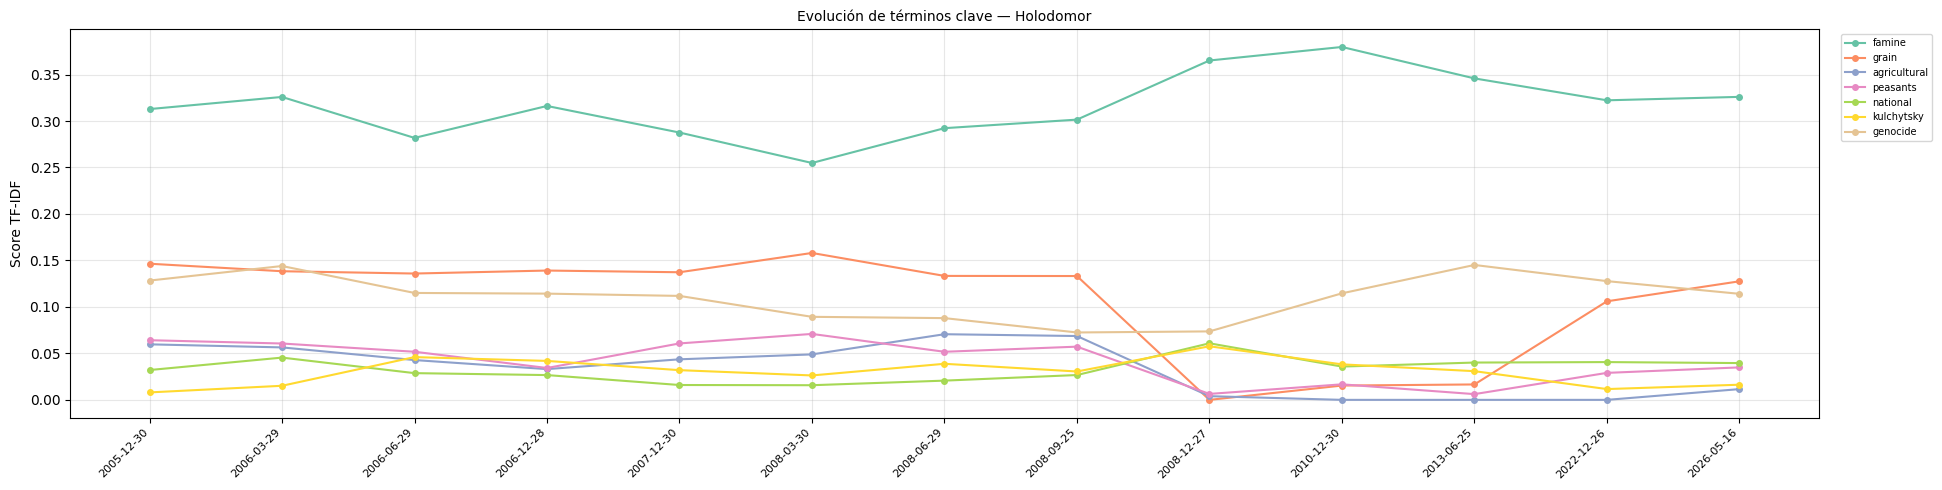

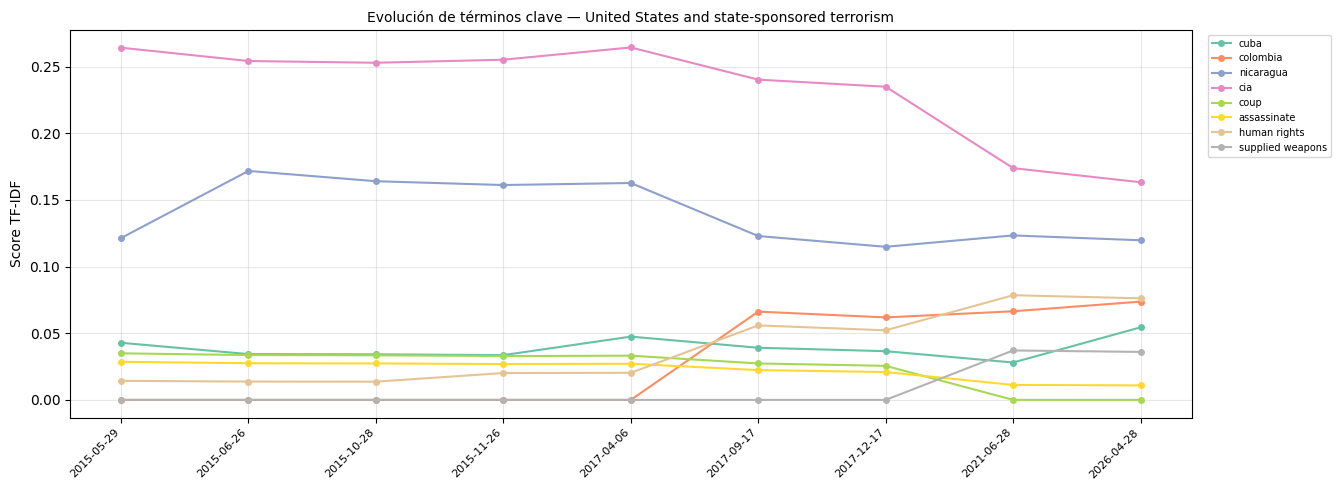

In [57]:
def plot_tfidf_bump(tfidf_results: dict, snapshot_data: dict, 
                    terms_of_interest: dict | None = None, top_n: int = 10):
    """
    Sigue la relevancia TF-IDF de términos seleccionados a lo largo de
    todos los snapshots, no solo los disruptivos.

    terms_of_interest: dict {title: [term1, term2, ...]}
    Si es None, selecciona automáticamente los top_n términos más
    variables entre el primer y último snapshot.
    """
    col_dropped = "#8DA0A8"
    col_added = "#66C2A5"
    colors = plt.cm.Set2.colors

    for title, snapshots in snapshot_data.items():
        if len(snapshots) < 2:
            continue

        texts = [" ".join(s["paragraphs"]) for s in snapshots]
        dates = [s["timestamp"][:10] for s in snapshots]

        vectorizer = TfidfVectorizer(
            max_features=5000,
            stop_words="english",
            ngram_range=(1, 2),
        )
        tfidf_matrix = vectorizer.fit_transform(texts)
        terms = vectorizer.get_feature_names_out()
        scores = tfidf_matrix.toarray()  # shape: (n_snapshots, n_terms)

        # Seleccionar términos a seguir
        if terms_of_interest and title in terms_of_interest:
            selected_terms = terms_of_interest[title]
            selected_idx = [np.where(terms == t)[0][0]
                            for t in selected_terms if t in terms]
        else:
            # Automático: términos con mayor varianza entre snapshots
            variance = scores.var(axis=0)
            selected_idx = variance.argsort()[::-1][:top_n]
            selected_terms = [terms[i] for i in selected_idx]

        fig, ax = plt.subplots(figsize=(max(8, len(dates) * 1.5), 5))
        x = np.arange(len(dates))

        for j, (idx, term) in enumerate(zip(selected_idx, selected_terms)):
            series = scores[:, idx]
            color = colors[j % len(colors)]
            ax.plot(x, series, marker="o", label=term, color=color,
                    linewidth=1.5, markersize=4)

        ax.set_xticks(x)
        ax.set_xticklabels(dates, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("Score TF-IDF")
        ax.set_title(f"Evolución de términos clave — {title[:55]}", fontsize=10)
        ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_tfidf_bump(tfidf_results, snapshot_data, terms_of_interest={
    "Holodomor": [
        "famine", "grain", "agricultural", "peasants",
        "national", "kulchytsky", "genocide",
    ],
    "United States and state-sponsored terrorism": [
        "cuba", "colombia", "nicaragua",
        "cia", "coup", "assassinate", "human rights", "supplied weapons", "United States"
    ],
})

## Inspección de párrafos sin correspondencia

Lista párrafos eliminados y añadidos en cada intervalo para revisión manual.

In [49]:
def print_unmatched(result: dict, direction: str = "dropped", max_chars: int = 400):
    """Imprime párrafos sin correspondencia para inspección manual."""
    label = "eliminados de A" if direction == "dropped" else "añadidos en B"
    key = "dropped_paras" if direction == "dropped" else "added_paras"
    items = result[key]
    print(f"\n{result['title']} | {result['date_a']} → {result['date_b']}")
    print(f"Párrafos {label} (sim < {THRESHOLD}): {len(items)}")
    for i, (para, sim) in enumerate(items):
        print(f"  [{i}] sim={sim:.3f}\n  {para[:max_chars]}")
        if len(para) > max_chars:
            print(f"  ... ({len(para) - max_chars} chars más)")


# Seleccionar intervalo por artículo y fechas
def inspect_interval(title: str, date_a: str, direction: str = "dropped"):
    series = drift_series[title]
    match = [r for r in series if r["date_a"].startswith(date_a)]
    if not match:
        print(f"No se encontró intervalo con date_a={date_a}")
        return
    print_unmatched(match[0], direction=direction)

# Ejemplos de uso:
inspect_interval("Holodomor", "2008-09-25", direction="dropped")
inspect_interval("Holodomor", "2008-09-25", direction="added")


Holodomor | 2008-09-25 → 2008-12-27
Párrafos eliminados de A (sim < 0.8): 67
  [0] sim=0.780
  Causes and outcomes thumb|350px|Map of the Ukrainian SSR in 1932-1933 (7 Oblasts and Moldavian ASSR) administrative borders given in light gray.thumb|right|Cover of the Soviet magazine Kolhospnytsia Ukrayiny ("Collective Farm Woman of Ukraine"), December 1932 While a complex task, it is possible to group some of the causes that contributed to the Holodomor. They have to be understood in the larger
  ... (270 chars más)
  [1] sim=0.559
  Approaches to changing from individual farming to a collective type of agricultural production had existed since 1917, but for various reasons (lack of agricultural equipment, agronomy resources, etc.) were not implemented widely until 1925, when there was a more intensive effort by the agricultural sector to increase the number of agricultural cooperatives and bolster the effectiveness of already
  ... (232 chars más)
  [2] sim=0.734
  In 1927, a drought sho

In [55]:
inspect_interval("United States and state-sponsored terrorism", "2017-04-06", direction="dropped")
inspect_interval("United States and state-sponsored terrorism", "2017-04-06", direction="added")


United States and state-sponsored terrorism | 2017-04-06 → 2017-09-17
Párrafos eliminados de A (sim < 0.8): 0

United States and state-sponsored terrorism | 2017-04-06 → 2017-09-17
Párrafos añadidos en B (sim < 0.8): 11
  [0] sim=0.611
  thumb|right|250px|US General William P. Yarborough was the head of a counterinsurgency team sent to Colombia in 1962 by the US Special Warfare Center. Yarborough was one of the earliest proponents of "paramilitary [...] and/or terrorist activities against known communist proponents". Colombian paramilitary groups were responsible for most of the human rights violations in the latter half of the on
  ... (936 chars más)
  [1] sim=0.515
  Plan Lazo In October 1959, the United States sent a "Special Survey Team", composed of counterinsurgency experts, to investigate Colombia's internal security situation, due to the increased prevalence of armed communist groups in rural Colombia which formed during and after La Violencia.Rempe, 1995  Three years later, 

In [56]:
inspect_interval("United States and state-sponsored terrorism", "2017-12-17", direction="dropped")
inspect_interval("United States and state-sponsored terrorism", "2017-12-17", direction="added")


United States and state-sponsored terrorism | 2017-12-17 → 2021-06-28
Párrafos eliminados de A (sim < 0.8): 11
  [0] sim=0.459
  On 11 April 1955 the “Kashmir Princess,” an Air India Constellation passenger airliner, was damaged in midair by a bomb explosion and crashed into the South China Sea while en route from Bombay (today Mumbai), India, and Hong Kong to Jakarta, Indonesia. Sixteen of those on board were killed, while three survived. The explosion had been caused by a time bomb placed aboard the aircraft by a Kuominta
  ... (401 chars más)
  [1] sim=0.448
  The Hong Kong authorities offered HK$100,000 for information leading to the arrest of those responsible. They questioned 71 people connected with servicing the Air India flight. The police eventually charged Chow Tse-ming, a janitor for Hong Kong Aircraft Engineering Co., with conspiracy to commit murder. The suspect, who held three aliases, fled to Taiwan on a CIA-owned Civil Air Transport aircra
  ... (15 chars más)
  [2] s

## Visualización: serie temporal de drift

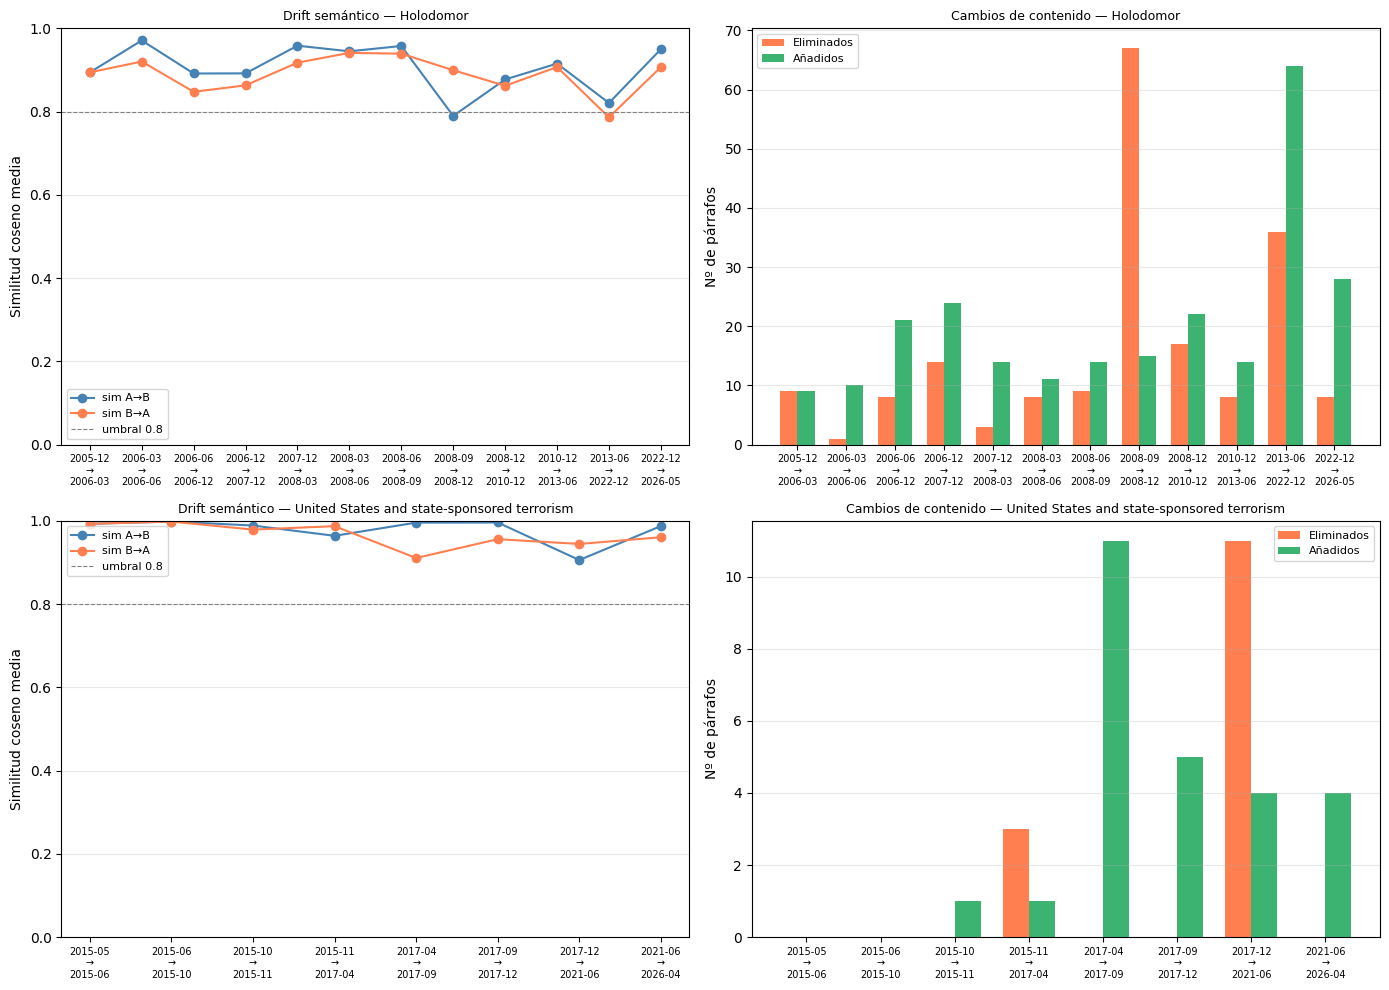

In [39]:
def plot_drift_series(drift_series: dict, threshold: float = THRESHOLD):
    n_articles = len(drift_series)
    fig, axes = plt.subplots(n_articles, 2, figsize=(14, 5 * n_articles))

    # Normalizar indexación para un solo artículo
    if n_articles == 1:
        axes = [axes]

    for row_idx, (title, series) in enumerate(drift_series.items()):
        if not series:
            continue

        dates = [f"{r['date_a'][:7]}\n→\n{r['date_b'][:7]}" for r in series]
        x = np.arange(len(series))

        # --- Panel izquierdo: similitudes por intervalo ---
        ax_sim = axes[row_idx][0]
        ax_sim.plot(x, [r["mean_sim_a_to_b"] for r in series],
                    marker="o", label="sim A→B", color="steelblue")
        ax_sim.plot(x, [r["mean_sim_b_to_a"] for r in series],
                    marker="o", label="sim B→A", color="coral")
        ax_sim.axhline(threshold, color="gray", linestyle="--", linewidth=0.8,
                       label=f"umbral {threshold}")
        ax_sim.set_xticks(x)
        ax_sim.set_xticklabels(dates, fontsize=7)
        ax_sim.set_ylim(0, 1)
        ax_sim.set_ylabel("Similitud coseno media")
        ax_sim.set_title(f"Drift semántico — {title[:45]}", fontsize=9)
        ax_sim.legend(fontsize=8)
        ax_sim.grid(axis="y", alpha=0.3)

        # --- Panel derecho: párrafos eliminados y añadidos ---
        ax_chg = axes[row_idx][1]
        width = 0.35
        ax_chg.bar(x - width / 2, [r["dropped"] for r in series],
                   width, label="Eliminados", color="coral")
        ax_chg.bar(x + width / 2, [r["added"] for r in series],
                   width, label="Añadidos", color="mediumseagreen")
        ax_chg.set_xticks(x)
        ax_chg.set_xticklabels(dates, fontsize=7)
        ax_chg.set_ylabel("Nº de párrafos")
        ax_chg.set_title(f"Cambios de contenido — {title[:45]}", fontsize=9)
        ax_chg.legend(fontsize=8)
        ax_chg.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_drift_series(drift_series)

## Distribución de similitudes

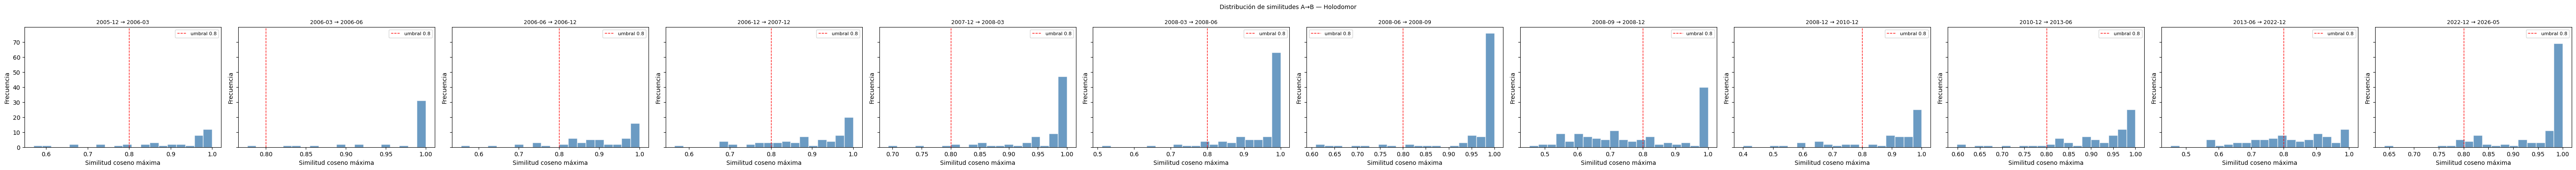

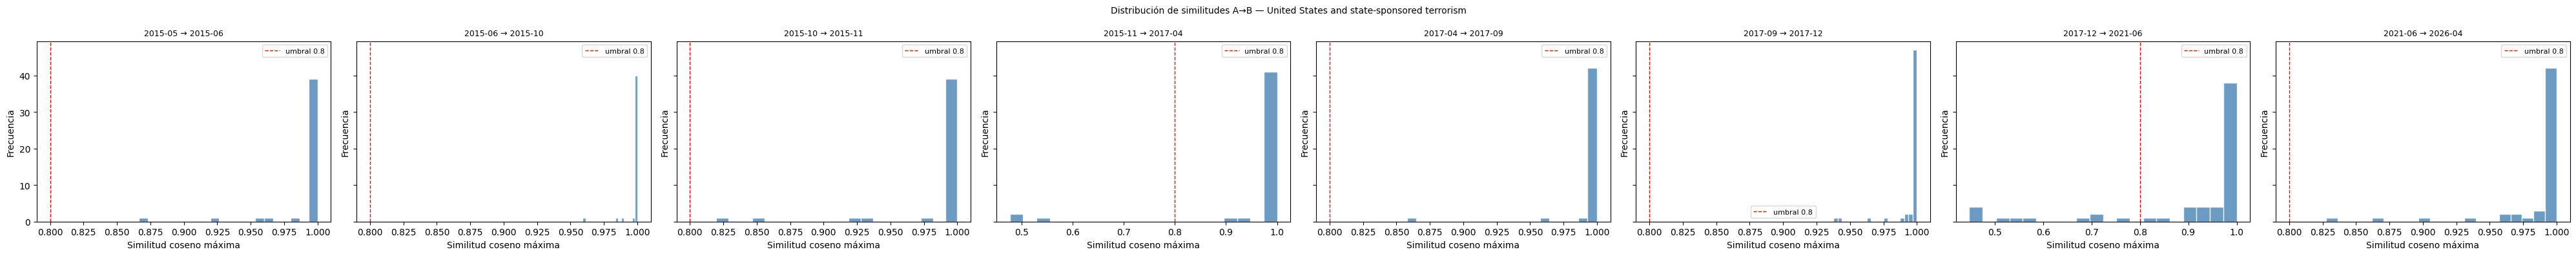

In [50]:
def plot_similarity_distributions(drift_series: dict, threshold: float = THRESHOLD):
    """Histograma de similitudes máximas A→B para cada intervalo."""
    for title, series in drift_series.items():
        n = len(series)
        if n == 0:
            continue
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
        if n == 1:
            axes = [axes]
        for ax, result in zip(axes, series):
            # Recalcular similitudes desde la matriz guardada
            a_to_b = result["sim_matrix"].max(axis=1)
            ax.hist(a_to_b, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
            ax.axvline(threshold, color="red", linestyle="--", linewidth=1,
                       label=f"umbral {threshold}")
            ax.set_xlabel("Similitud coseno máxima")
            ax.set_ylabel("Frecuencia")
            ax.set_title(f"{result['date_a'][:7]} → {result['date_b'][:7]}", fontsize=9)
            ax.legend(fontsize=8)
        fig.suptitle(f"Distribución de similitudes A→B — {title[:50]}", fontsize=10)
        plt.tight_layout()
        plt.show()


plot_similarity_distributions(drift_series)

In [53]:
def inspect_similarity_range(title: str, date_a: str, sim_low: float = 0.80, sim_high: float = 0.90, max_pairs: int = 10):
    """
    Muestra pares de párrafos cuya similitud máxima A->B cae en el rango [sim_low, sim_high].
    Para cada párrafo de A se muestra también su mejor match en B.
    """
    series = drift_series[title]
    match = [r for r in series if r["date_a"].startswith(date_a)]
    if not match:
        print(f"No se encontró intervalo con date_a={date_a}")
        return
    result = match[0]
    snapshots = snapshot_data[title]
    snap_a = next(s for s in snapshots if s["timestamp"][:10] == result["date_a"])
    snap_b = next(s for s in snapshots if s["timestamp"][:10] == result["date_b"])

    a_to_b = result["sim_matrix"].max(axis=1)
    best_match_idx = result["sim_matrix"].argmax(axis=1)

    in_range = np.where((a_to_b >= sim_low) & (a_to_b < sim_high))[0]
    print(f"\n{title} | {result['date_a']} -> {result['date_b']}")
    print(f"Párrafos de A con similitud en [{sim_low}, {sim_high}): {len(in_range)}")

    for i in in_range[:max_pairs]:
        sim = a_to_b[i]
        para_a = snap_a["paragraphs"][i]
        para_b = snap_b["paragraphs"][best_match_idx[i]]
        print(f"\n  [sim={sim:.3f}]")
        print(f"  A: {para_a[:300]}")
        print(f"  B: {para_b[:300]}")
        print(f"  {'='*60}")


# Inspecciona el intervalo más interesante del artículo de US
inspect_similarity_range(
    "United States and state-sponsored terrorism",
    "2017-04-06",
    sim_low=0.80,
    sim_high=0.90,
)


United States and state-sponsored terrorism | 2017-04-06 -> 2017-09-17
Párrafos de A con similitud en [0.8, 0.9): 1

  [sim=0.858]
  A: The Sandinista government headed by Daniel Ortega won decisively in the 1984 Nicaraguan elections. The national elections of 1984 were conducted during a state of emergency officially justified by the war fought against the Contras insurgents and the CIA-orchestrated bombings. Many political prisone
  B: The Sandinista government headed by Daniel Ortega won decisively in the 1984 Nicaraguan elections. The U.S. government explicitly planned to back the Contras, various rebel groups collectively that were formed in response to the rise of the Sandinistas, as a means to damage the Nicaraguan economy an


In [54]:
for date in ["2015-05-29", "2015-06-26", "2015-10-28", "2015-11-26", 
             "2017-04-06", "2017-09-17", "2017-12-17", "2021-06-28"]:
    inspect_similarity_range(
        "United States and state-sponsored terrorism",
        date,
        sim_low=0.70,
        sim_high=0.90,
    )


United States and state-sponsored terrorism | 2015-05-29 -> 2015-06-26
Párrafos de A con similitud en [0.7, 0.9): 1

  [sim=0.866]
  A: The Sandinistas did not attempt to create a communist economic system; instead, their policy advocated a social democracy and a mixed economy.LaFeber, p. 350LaFeber, p. 238Latin American Studies Association, p. 5"Soviet posture in the Western Hemisphere" Carl G. Jacobsen, 28 February 1985, p. 6Grand
  B: The Sandinistas did not attempt to create a communist economic system; instead, their policy advocated a social democracy and a mixed economy.LaFeber, p. 350LaFeber, p. 238Latin American Studies Association, p. 5"Soviet posture in the Western Hemisphere" Carl G. Jacobsen, 28 February 1985, p. 6Grand

United States and state-sponsored terrorism | 2015-06-26 -> 2015-10-28
Párrafos de A con similitud en [0.7, 0.9): 0

United States and state-sponsored terrorism | 2015-10-28 -> 2015-11-26
Párrafos de A con similitud en [0.7, 0.9): 2

  [sim=0.820]
  A: As

## Tabla resumen

In [51]:
rows = []
for title, series in drift_series.items():
    for r in series:
        rows.append({
            "Artículo": title[:40],
            "Desde": r["date_a"],
            "Hasta": r["date_b"],
            "Párrafos A": r["n_paras_a"],
            "Párrafos B": r["n_paras_b"],
            "Sim A→B": r["mean_sim_a_to_b"],
            "Sim B→A": r["mean_sim_b_to_a"],
            "Eliminados": r["dropped"],
            "Añadidos": r["added"],
        })

summary = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
display(summary)

,Artículo,Desde,Hasta,Párrafos A,Párrafos B,Sim A→B,Sim B→A,Eliminados,Añadidos
0,Holodomor,2005-12-30,2006-03-29,40,42,0.8941,0.8941,9,9
1,Holodomor,2006-03-29,2006-06-29,42,55,0.9709,0.9203,1,10
2,Holodomor,2006-06-29,2006-12-28,55,70,0.8915,0.8475,8,21
3,Holodomor,2006-12-28,2007-12-30,70,82,0.8918,0.8630,14,24
4,Holodomor,2007-12-30,2008-03-30,82,106,0.9583,0.9176,3,14
5,Holodomor,2008-03-30,2008-06-29,106,109,0.9433,0.9416,9,11
6,Holodomor,2008-06-29,2008-09-25,109,128,0.9585,0.9380,9,15
7,Holodomor,2008-09-25,2008-12-27,128,67,0.7896,0.8994,67,15
8,Holodomor,2008-12-27,2010-12-30,67,80,0.8772,0.8621,17,22
9,Holodomor,2010-12-30,2013-06-25,80,84,0.9153,0.9069,8,14


In [ ]:
summary.to_csv("diacronica_par_5.csv", index=False, encoding="utf-8-sig")